In [1]:
!pip install --upgrade pip --quiet

ERROR: To modify pip, please run the following command:
C:\Users\jlvar\anaconda3\envs\llm\python.exe -m pip install --upgrade pip --quiet


In [2]:
# ===============================
# 🔹 Instalación de dependencias base
# ===============================
!pip install -U pandas==2.2.2 scikit-learn==1.4.2 matplotlib seaborn nltk==3.8.1 --quiet

# ===============================
# 🔹 Librerías de procesamiento de lenguaje y embeddings
# ===============================
!pip install -U gensim==4.3.2 scipy==1.11.4 --quiet

# ===============================
# 🔹 Librerías para modelos de deep learning y Transformers
# ===============================
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu --quiet
!pip install -U transformers==4.41.2 protobuf==3.20.3 --quiet
!pip install transformers[torch]


In [3]:
!pip install keras==2.15.0 tensorflow==2.15.0 --quiet

In [4]:

# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import torch

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from transformers import (BertTokenizer, BertForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
url = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/03%20-%20NLP/amazon_reviews.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [6]:
data = df[['reviewText', 'overall']].copy()
data.head()

,reviewText,overall
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


In [7]:
# Transformar la columna 'overall' a categorías de sentimiento binario
# Positivo: 1 si la calificación es mayor o igual a 4
# Negativo: 0 si la calificación es menor a 4

data['sentiment'] = data['overall'].apply(lambda x: 1 if x >= 4 else 0)

# Verificar la transformación
data[['overall', 'sentiment']].head()


,overall,sentiment
0,4.0,1
1,5.0,1
2,4.0,1
3,5.0,1
4,5.0,1


C:\Users\jlvar\AppData\Local\Temp\ipykernel_28832\1918538385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment', palette='viridis')


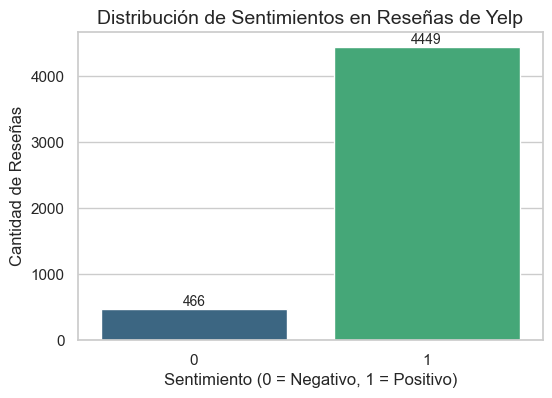

In [8]:

# Configuración del estilo
sns.set(style="whitegrid")

#  Gráfico de barras para la columna 'sentiment'
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='sentiment', palette='viridis')

# Etiquetas y título
plt.title('Distribución de Sentimientos en Reseñas de Yelp', fontsize=14)
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)

# Mostrar etiquetas encima de las barras
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, 
             p.get_height() + 50, 
             f'{int(p.get_height())}', 
             ha='center', fontsize=10)

plt.show()


C:\Users\jlvar\AppData\Local\Temp\ipykernel_28832\740073135.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanceado, x='sentiment', palette='viridis')


sentiment
1    466
0    466
Name: count, dtype: int64


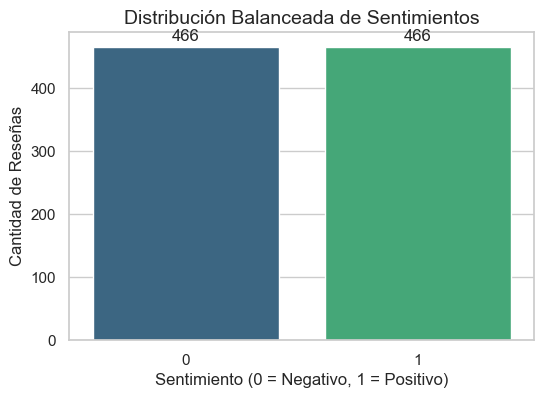

In [9]:
# Balancear las clases: undersampling de la clase positiva
negativos = data[data['sentiment'] == 0]
positivos = data[data['sentiment'] == 1].sample(n=len(negativos), random_state=42)

# Combinar ambos subconjuntos
df_balanceado = pd.concat([negativos, positivos]).sample(frac=1, random_state=42).reset_index(drop=True)

# Verificar el balance
print(df_balanceado['sentiment'].value_counts())

# Visualizar nuevamente
plt.figure(figsize=(6,4))
sns.countplot(data=df_balanceado, x='sentiment', palette='viridis')
plt.title('Distribución Balanceada de Sentimientos', fontsize=14)
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad de Reseñas')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height() + 10, f'{int(p.get_height())}', ha='center')

plt.show()


In [10]:
df_balanceado = df_balanceado.drop(columns=['overall'])
df_balanceado.head()

,reviewText,sentiment
0,Great price for 32gb SD card; It was delivered...,1
1,This does not appear to work with the Samsung ...,0
2,Not a bad product at all. I got it for my blac...,1
3,The cards have had no reliability issues at th...,1
4,SanDisk is well know brand. The MSD Ultra 64 G...,1


## 2. Preprocesamiento del Texto

In [11]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)               # eliminar caracteres especiales
    tokens = nltk.word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df_balanceado['clean_text'] = df_balanceado['reviewText'].apply(limpiar_texto)
df_balanceado.head()


,reviewText,sentiment,clean_text
0,Great price for 32gb SD card; It was delivered...,1,great price gb sd card delivered time got down...
1,This does not appear to work with the Samsung ...,0,appear work samsung galaxy worked week phone s...
2,Not a bad product at all. I got it for my blac...,1,bad product got blackberry z format phone soft...
3,The cards have had no reliability issues at th...,1,card reliability issue required task put data ...
4,SanDisk is well know brand. The MSD Ultra 64 G...,1,sandisk well know brand msd ultra gb class goo...


In [12]:
df_balanceado = df_balanceado.drop(columns=['reviewText'])
df_balanceado.head()

,sentiment,clean_text
0,1,great price gb sd card delivered time got down...
1,0,appear work samsung galaxy worked week phone s...
2,1,bad product got blackberry z format phone soft...
3,1,card reliability issue required task put data ...
4,1,sandisk well know brand msd ultra gb class goo...


## 3. Representación del Texto (Word Embeddings)

In [13]:

from gensim.models import Word2Vec

# Tokenizar las reseñas
tokens = [nltk.word_tokenize(text) for text in df_balanceado['clean_text']]
model_w2v = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=5, workers=4)

# Ejemplo: vector de una palabra
model_w2v.wv['good']

array([-0.20182523,  0.35831556,  0.18938535,  0.07696321,  0.28904882,
       -0.54830927,  0.12398224,  0.80526495, -0.22436234, -0.3549091 ,
       -0.32279077, -0.55719066,  0.04385405,  0.21181315,  0.16429986,
       -0.20499524,  0.03927802, -0.28142118, -0.16111836, -0.8673455 ,
        0.11906134,  0.06916039,  0.01925828, -0.18188639, -0.10879495,
        0.045508  , -0.2665743 , -0.3785352 , -0.13543867,  0.10522849,
        0.31832728,  0.15671125,  0.11039694, -0.29537502, -0.29982907,
        0.56180215,  0.14130786, -0.34742433, -0.19370167, -0.66980886,
        0.00686947, -0.20722008, -0.00707537, -0.07129355,  0.4283094 ,
       -0.06448756, -0.30187964,  0.00896162,  0.3656806 ,  0.03878348,
        0.21798788, -0.36705714, -0.01372692,  0.03496875, -0.3044216 ,
        0.21973889,  0.17430314, -0.10971671, -0.42953202,  0.20721158,
        0.14991342,  0.16453804, -0.07483266, -0.05847371, -0.34070584,
        0.25255236,  0.06835727,  0.35742676, -0.6038008 ,  0.48

## 4. Modelo Secuencial (LSTM/GRU)

In [14]:

import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3, bidirectional=True):
        super(SentimentLSTM, self).__init__()

        # Capa de embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Capa LSTM (bidireccional, multicapa, con dropout)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True,
            dropout=dropout
        )
        
        # Capa fully connected
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, output_dim)
        
        # Dropout adicional
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        
        # Tomamos la última salida (último timestep)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out  # Sin softmax


In [15]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
import numpy as np

# Tokenización
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_balanceado['clean_text'])
sequences = tokenizer.texts_to_sequences(df_balanceado['clean_text'])

# Padding
max_len = 100  # longitud máxima de las reseñas
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Etiquetas
y = df_balanceado['sentiment'].values

# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tensores
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# DataLoader
batch_size = 32
train_data = TensorDataset(X_train_t, y_train_t)
test_data = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)


In [16]:
vocab_size = len(tokenizer.word_index) + 1  # tamaño del vocabulario
embedding_dim = 100
hidden_dim = 128
output_dim = 2  # positivo o negativo

model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [17]:
epochs = 50
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"📘 Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")


📘 Epoch 1/50, Loss: 0.6971
📘 Epoch 2/50, Loss: 0.6919
📘 Epoch 3/50, Loss: 0.6851
📘 Epoch 4/50, Loss: 0.6698
📘 Epoch 5/50, Loss: 0.6736
📘 Epoch 6/50, Loss: 0.6641
📘 Epoch 7/50, Loss: 0.6615
📘 Epoch 8/50, Loss: 0.6839
📘 Epoch 9/50, Loss: 0.6657
📘 Epoch 10/50, Loss: 0.6663
📘 Epoch 11/50, Loss: 0.6598
📘 Epoch 12/50, Loss: 0.6597
📘 Epoch 13/50, Loss: 0.6607
📘 Epoch 14/50, Loss: 0.6599
📘 Epoch 15/50, Loss: 0.6623
📘 Epoch 16/50, Loss: 0.6558
📘 Epoch 17/50, Loss: 0.6463
📘 Epoch 18/50, Loss: 0.6193
📘 Epoch 19/50, Loss: 0.6108
📘 Epoch 20/50, Loss: 0.5770
📘 Epoch 21/50, Loss: 0.5220
📘 Epoch 22/50, Loss: 0.4976
📘 Epoch 23/50, Loss: 0.4539
📘 Epoch 24/50, Loss: 0.5521
📘 Epoch 25/50, Loss: 0.4579
📘 Epoch 26/50, Loss: 0.3979
📘 Epoch 27/50, Loss: 0.3907
📘 Epoch 28/50, Loss: 0.3783
📘 Epoch 29/50, Loss: 0.4370
📘 Epoch 30/50, Loss: 0.3598
📘 Epoch 31/50, Loss: 0.3354
📘 Epoch 32/50, Loss: 0.2950
📘 Epoch 33/50, Loss: 0.3077
📘 Epoch 34/50, Loss: 0.2801
📘 Epoch 35/50, Loss: 0.2645
📘 Epoch 36/50, Loss: 0.3148
📘

In [18]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"✅ Accuracy: {100 * correct / total:.2f}%")


✅ Accuracy: 82.35%


In [19]:
def predecir_sentimiento(texto):
    seq = tokenizer.texts_to_sequences([texto])
    seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    seq_t = torch.tensor(seq, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        output = model(seq_t)
        pred = torch.argmax(output, dim=1).item()
    return "Positivo 😀" if pred == 1 else "Negativo 😞"

# Ejemplo
print(predecir_sentimiento("The food was terrible and cold"))
print(predecir_sentimiento("Amazing service and delicious pizza!"))


Negativo 😞
Positivo 😀


In [20]:
torch.save(model.state_dict(), "sentiment_lstm_amz.pth")

## 5. Modelo basado en Transformers (BERT)

In [21]:

# Cargar modelo preentrenado BERT base
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

for name, param in model.named_parameters():
    if "classifier" in name or "encoder.layer.11" in name or "encoder.layer.10" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
        
# Ejemplo de tokenización
sample = tokenizer("This product is amazing!", return_tensors="pt")
outputs = model(**sample)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )   
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }



In [29]:
# Tras el train_test_split
X_train = X_train.reset_index(drop=True).tolist()
X_val   = X_val.reset_index(drop=True).tolist()
y_train = pd.Series(y_train).reset_index(drop=True).tolist()
y_val   = pd.Series(y_val).reset_index(drop=True).tolist()

train_ds = TextDataset(X_train, y_train, tokenizer, max_len=128)
val_ds   = TextDataset(X_val,   y_val,   tokenizer, max_len=128)


In [30]:

# ---  Collator y métricas
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# ---  Args de entrenamiento
training_args = TrainingArguments(
    output_dir='./results_bert',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs_bert',
    logging_steps=50,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    seed=42,
)

#  Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [ ]:
# Entrenar, evaluar y guardar
trainer.train()
metrics = trainer.evaluate()
print(metrics)

trainer.save_model('./bert_amz_partial_ft')
tokenizer.save_pretrained('./bert_amz_partial_ft')

  0%|          | 0/282 [03:44<?, ?it/s]
c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                                       
  0%|          | 0/282 [04:43<?, ?it/s]         

{'loss': 0.6908, 'grad_norm': 7.485458850860596, 'learning_rate': 1.645390070921986e-05, 'epoch': 0.53}


In [ ]:
# ---  Predicción en texto nuevo
def predict_text(text, max_len=128):
    enc = tokenizer(text, truncation=True, padding='max_length',
                    max_length=max_len, return_tensors='pt')
    with torch.no_grad():
        out = model(**{k: v.to(model.device) for k, v in enc.items()})
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy().ravel()
    pred = int(probs.argmax())
    return {'pred': pred, 'probs': probs}  # 0=neg, 1=pos

print(predict_text("Amazing food and great service!"))
print(predict_text("Terrible experience, I won't come back."))

## 6. Evaluación de los Modelos

c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.50      1.00      0.67         1
           2       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



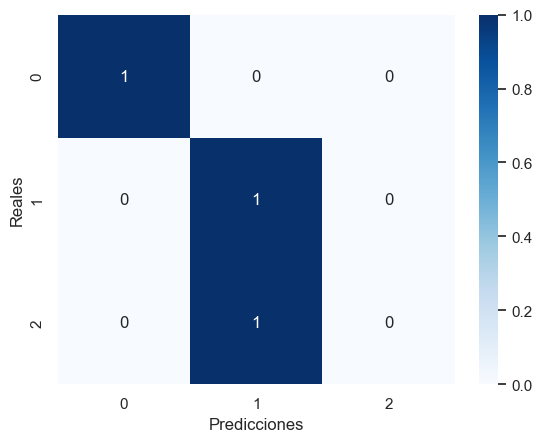